# Fase 0: Introduzione

In questo Jupyter Notebook sarà possibile consultare la realizzazione del primo obiettivo del Project Work "Triage automatico dei ticket con Machine Learning". Gli obiettivi da raggiungere sono:
- *Pipeline ML*
    - Preprocessing: pulizia base del testo (minuscole, rimozione punteggiatura), tokenizzazione.
    - Modello classificazione categoria (Amministrazione/Tecnico/Commerciale).
    - Modello stima priorità (Bassa/Media/Alta).
    - Valutazione: train/test 80/20, accuracy e F1 macro; matrice di confusione.

Nello specifico, viene presentata un'analisi dei processi esplorazione, pulizia e modellazione predittiva applicati ai dataset creati in precedenza. Sarà possibile modificare il nome del dataset dalla prima cella di codice per testare le differenze.
- Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)
    - In questa fase iniziale si esegue il caricamento del dataset e una prima ispezione per verificarne la struttura. Viene analizzata la distribuzione delle categorie e della priorità grazie all'ausilio di diversi grafici. Inoltre, viene approfondita la struttura testuale calcolando la lunghezza delle parole all'interno del corpo dei ticket
- Fase 2: Preprocessing
    - Qui viene implementata una funzione di pulizia del testo basata sulle espressioni regolari per standardizzare la struttura dei record, rimuovendo in maniera particolare la punteggiatura e i caratteri speciali, preparando la base di dati alla successiva fase di vettorizzazione.
- Fase 3: Modello classificazione categoria
    - In questa fase vengono esplorate le varie strategie adottate per creare un modello di classificazione delle categorie dei vari ticket
- Fase 4: Modello classificazione priorità
    - In questa fase ci si concentra invece sulle varie strategie adottate per la stima della priorità dei vari ticket, testando l'efficacia dei modelli predittivi su classi che presentano distribuzioni differenti.
- Fase 5: Esportazione dei modelli
    Salvataggio definitivo dei modelli che hanno ottenuto la migliore prestazione per creazione della dashboard
- Fase 6: Valutazione generale dei vari modelli nei dataset analizzati
    - Il notebook terminerà con un'analisi generale dei modelli sui 3 dataset presi come riferimento

In [3]:
dataset = "gemma_definitiva.csv"

# Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)

In [4]:
import pandas as pd
df = pd.read_csv(dataset)
df.sample(10)

,id,title,body,category,priority
482,TK-482,Procedura per gestione fatture urgenti,Vi scrivo perché ho bisogno di assistenza imme...,Amministrazione,Alta
131,TK-131,Urgente: non va connessione VPN,La connessione VPN è completamente interrotta....,Tecnico,Alta
31,TK-31,Problema con l'aggiornamento dei dati amminist...,"Quando capita, potreste dare un'occhiata a que...",Amministrazione,Bassa
465,TK-465,Mancato funzionamento report mensile,"Mi serve supporto ora, sono fermo su la genera...",Amministrazione,Media
124,TK-124,Interruzione servizio su licenza software comm...,Ho bisogno di accesso immediato alla mia licen...,Commerciale,Alta
230,TK-230,Errore accesso server bloccato,Non riesco ad accedere al server. Ho provato a...,Tecnico,Alta
300,TK-300,Info per risoluzione urgente problema server,Ho un blocco critico sul server principale. Ri...,Tecnico,Alta
132,TK-132,Nota di aggiornamento su gestione flussi conta...,Ho riscontrato un lieve disallineamento nei re...,Amministrazione,Bassa
144,TK-144,EMERGENZA: Server offline e perdita di connett...,Impossibile procedere con il lavoro a causa di...,Tecnico,Alta
426,TK-426,Procedura per gestione licenze software,Ho bisogno di assistenza riguardo l'aggiorname...,Commerciale,Bassa


In [5]:
df['category'].value_counts(ascending=False)

category
Commerciale        178
Tecnico            163
Amministrazione    159
Name: count, dtype: int64

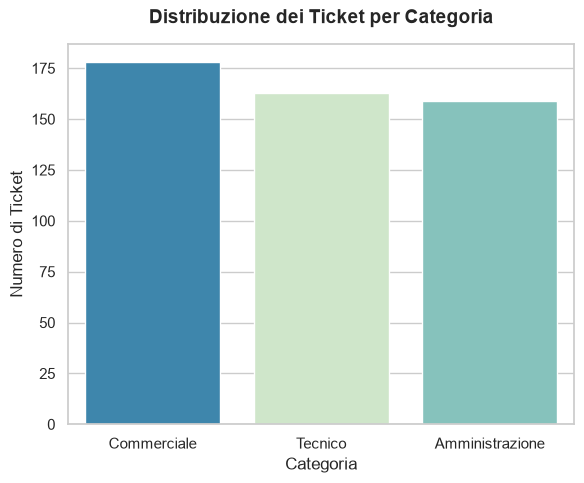

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

#GRAFICO 1: Numero di ticket per ogni categoria (in ordine decrescente)

#ordine delle categorie dal valore più alto al più basso
ordine_categorie = df['category'].value_counts().index

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='category', 
    order=ordine_categorie, 
    hue='category', 
    palette='GnBu_r', 
    ax=ax1
)

#rimuovo la legenda automatica del parametro 'hue' che in questo caso è ridondante
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax1.set_title('Distribuzione dei Ticket per Categoria', fontsize=14, pad=15, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=12)
ax1.set_ylabel('Numero di Ticket', fontsize=12)

plt.tight_layout()
plt.show()


In [7]:
df.groupby('category')['priority'].value_counts(ascending=False)

category         priority
Amministrazione  Alta        56
                 Bassa       55
                 Media       48
Commerciale      Alta        60
                 Media       60
                 Bassa       58
Tecnico          Bassa       63
                 Media       51
                 Alta        49
Name: count, dtype: int64

In [8]:
df['priority'].value_counts(ascending=False)

priority
Bassa    176
Alta     165
Media    159
Name: count, dtype: int64

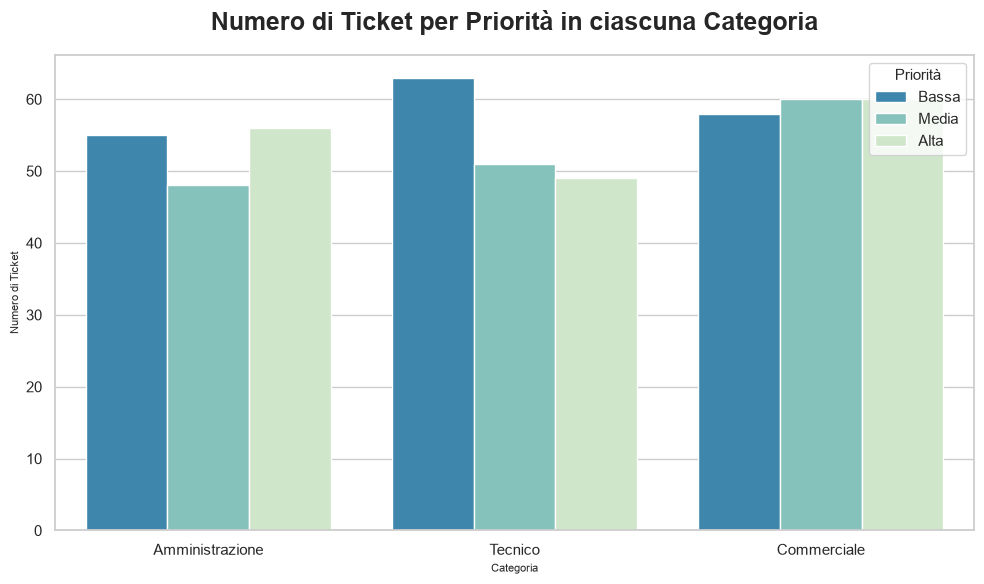

In [9]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

order = ['Amministrazione', 'Tecnico', 'Commerciale']
sns.countplot(
    data=df, 
    x='category',
    order = order, 
    hue='priority', 
    hue_order=['Bassa', 'Media', 'Alta'],
    palette='GnBu_r', 
    ax=ax2
)

#leggenda ed etichette varie
ax2.set_title('Numero di Ticket per Priorità in ciascuna Categoria', fontsize=18, pad=18, fontweight='bold')
ax2.set_xlabel('Categoria', fontsize=8)
ax2.set_ylabel('Numero di Ticket', fontsize=8)
ax2.legend(title='Priorità', title_fontsize='11', loc='upper right')


plt.tight_layout()
plt.show()

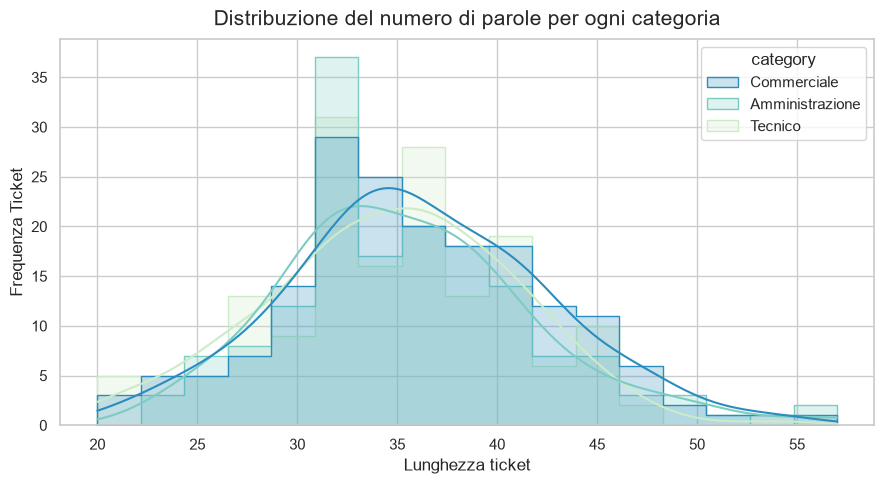

In [10]:
df['ticket_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')
df['word_count'] = df['ticket_completo'].apply(lambda x: len(x.split()))

#grafico della distribuzione della lunghezza
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='word_count', hue='category', kde=True, element='step', palette='GnBu_r', ax=ax)

ax.set_title('Distribuzione del numero di parole per ogni categoria', fontsize=15, pad=10)
ax.set_xlabel('Lunghezza ticket')
ax.set_ylabel('Frequenza Ticket')

plt.tight_layout()
plt.show()

# Fase 2: Preprocessing

Preprocessing del testo, ovvero pulizia base del testo (rimozione elemeni nan, minuscole, punteggiatura).

In [11]:
df = df.dropna(subset=['title','category', 'priority','body'])

La funzione *clean_text(text)* utilizza regex per rimuovere tutti gli elementi che non sono lettere o spazi. in più porta tutte le parole in miniscolo.

In [12]:
import re
import pandas as pd

def clean_text(text):
    
    text = str(text).lower()
    
    #^\w\s significa "tutto ciò che NON è una lettera/numero (\w) o uno spazio (\s)"
    text = re.sub(r'[^\w\s]', '', text)
    
    #rimuove spazi in generale
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


Esempio di pulizia in un record estratto casualmente:

In [13]:
test_record = df.sample(n=1)

print("--- RECORD REALE ESTRATTO ---")
print(test_record[['title','category', 'priority','body']])

print("\n--- RISULTATO DOPO LA PULIZIA ---")
clean_record = test_record[['title', 'category', 'priority','body']].map(clean_text)
print(clean_record)

--- RECORD REALE ESTRATTO ---
                                                title category priority  \
415  Suggerimento / Miglioria per configurazione rete  Tecnico    Bassa   

                                                  body  
415  Buongiorno! Ho riscontrato un piccolo inconven...  

--- RISULTATO DOPO LA PULIZIA ---
                                              title category priority  \
415  suggerimento miglioria per configurazione rete  tecnico    bassa   

                                                  body  
415  buongiorno ho riscontrato un piccolo inconveni...  


Processo di tokenizzazione. Per farlo, viene aggiunta una nuova colonna chiamata 'token'

In [14]:
df[['title', 'category', 'priority','body']]= df[['title', 'category', 'priority','body']].map(clean_text)

df['token'] = df['ticket_completo'].map(clean_text).str.split()
print(df['token'])

0      [avrei, bisogno, di, un, controllo, su, fattur...
1      [emergenza, problemi, con, lupload, delle, fat...
2      [emergenza, blocco, fatturazione, commerciale,...
3      [info, per, gestione, spese, ho, bisogno, di, ...
4      [bloccato, su, report, commerciali, di, q3, no...
                             ...                        
495    [assistenza, immediata, per, problema, conness...
496    [info, di, routine, per, troubleshooting, rete...
497    [richiesta, urgente, il, sistema, è, completam...
498    [urgente, non, va, la, fatturazione, ho, un, p...
499    [curiosità, tecnica, riguardo, a, configurazio...
Name: token, Length: 500, dtype: object


Altro EDA per analizzare le parole più frequenti nel dataset

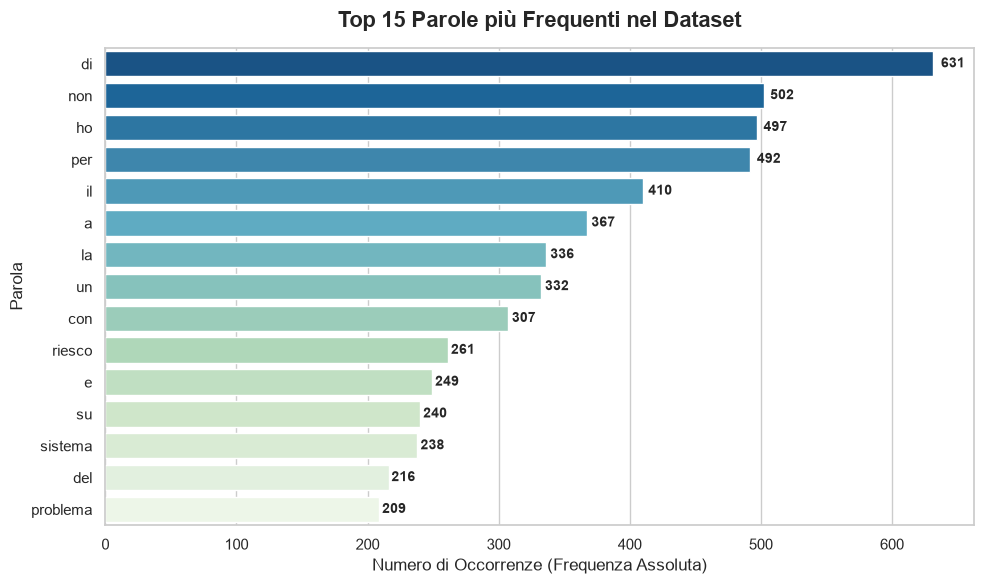

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = df['token'].explode().value_counts().head(15).reset_index()

top_words.columns = ['Parola', 'Frequenza']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") #sfondo pulito con griglia leggera

#grafico a barre orizzontali (barpot)
sns.barplot(
    x='Frequenza', 
    y='Parola', 
    data=top_words, 
    palette='GnBu_r', 
    hue='Parola',
    legend=False
)

#personalizza i testi e i titoli
plt.title('Top 15 Parole più Frequenti nel Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero di Occorrenze (Frequenza Assoluta)', fontsize=12)
plt.ylabel('Parola', fontsize=12)

#per mettere in risalto i valori numerici alla fine di ogni barra
for index, value in enumerate(top_words['Frequenza']):
    plt.text(value + (value * 0.01), index, f'{int(value)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

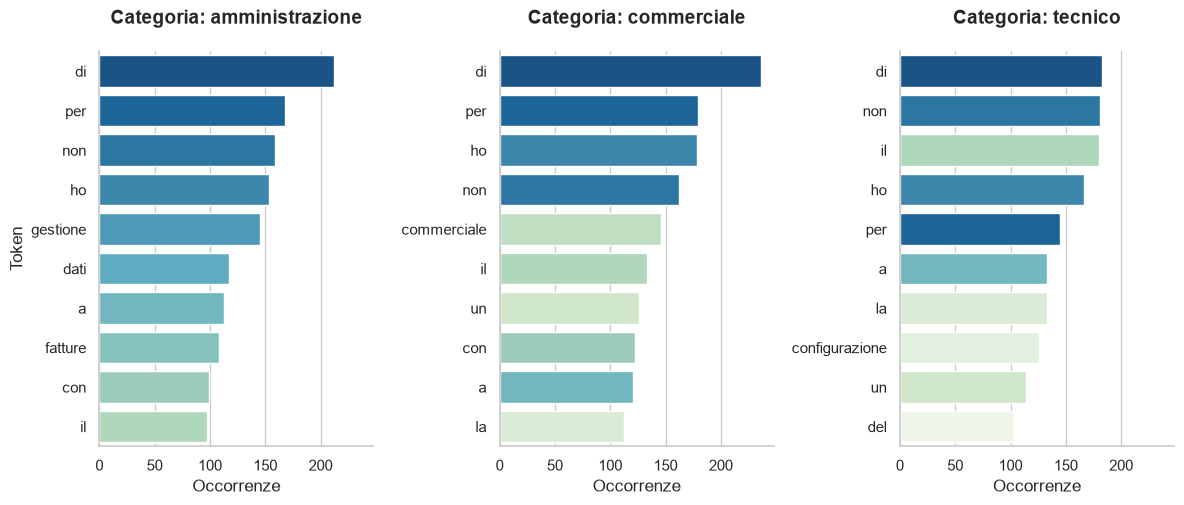

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
words_by_category = (df[['category', 'token']]
                     .explode('token')
                     .groupby(['category', 'token'])
                     .size()
                     .reset_index(name='Frequenza'))

#solo le top 10 parole per ogni singola categoria per non affollare il grafico
top_words_per_cat = (words_by_category
                     .sort_values(['category', 'Frequenza'], ascending=[True, False])
                     .groupby('category')
                     .head(10))

top_words_per_cat = top_words_per_cat.rename(columns={'token': 'Parola'})

g = sns.catplot(
    data=top_words_per_cat, 
    kind="bar",
    x="Frequenza",  
    y="Parola",
    col="category",
    palette="GnBu_r",
    hue="Parola",
    legend=False,
    sharey=False,
    height=5, 
    aspect=0.8
)

g.set_titles("Categoria: {col_name}", size=14, weight='bold',pad=20)
g.set_xlabels("Occorrenze", size=12)
g.set_ylabels("Token", size=12)


plt.show()

# Fase 3: Modello classificazione categoria:

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la categoria di un ticket. 

A seguire è presente un analisi degli algoritmi utilizzati con una loro valutazione sul dataset.

### Algoritmo di classificazione LinearSVC.

Citando Wikipedia:
- [Inglese](https://en.wikipedia.org/wiki/Support_vector_machine)
- [Italiano](https://it.wikipedia.org/wiki/Macchine_a_vettori_di_supporto)

"Le macchine a vettori di supporto (SVM, dall'inglese support-vector machines o networks) sono dei modelli di apprendimento supervisionato associati ad algoritmi di apprendimento per la regressione e la classificazione."

All'interno di questi modelli supervisionati, LinearSVC (Linear Support Vector Classifier) è una variante specializzata esclusivamente per compiti di classificazione in cui il confine tra le diverse categorie può essere tracciato mediante una linea retta 

Per poter utilizzare questo algoritmo, è stata necessaria compiere un azione di vettorizzazione dei ticket. Ho sfruttato la libreria [*TfidfVectorizer*](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) che ho ritenuta ottima per il problema in questione grazie alla sua capacità di trasformare il testo in vettori numerici pesati, evidenziando le parole chiave più rilevanti di ogni ticket ed escludendo il "rumore" di fondo della lingua parlata.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['category']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#estrazione delle Feature con TF-IDF
vectorizer_categoria = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=None #inserendo le stopword italiane con nltk il risultato peggiora
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_categoria.fit_transform(X_train)
X_test_tfidf = vectorizer_categoria.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_categoria = LinearSVC(random_state=42, dual=False)
modello_categoria.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_categoria.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---
Accuracy Totale: 0.9800

Report di Classificazione (comprende F1-Macro):
                 precision    recall  f1-score   support

amministrazione       0.94      1.00      0.97        32
    commerciale       1.00      0.94      0.97        36
        tecnico       1.00      1.00      1.00        32

       accuracy                           0.98       100
      macro avg       0.98      0.98      0.98       100
   weighted avg       0.98      0.98      0.98       100



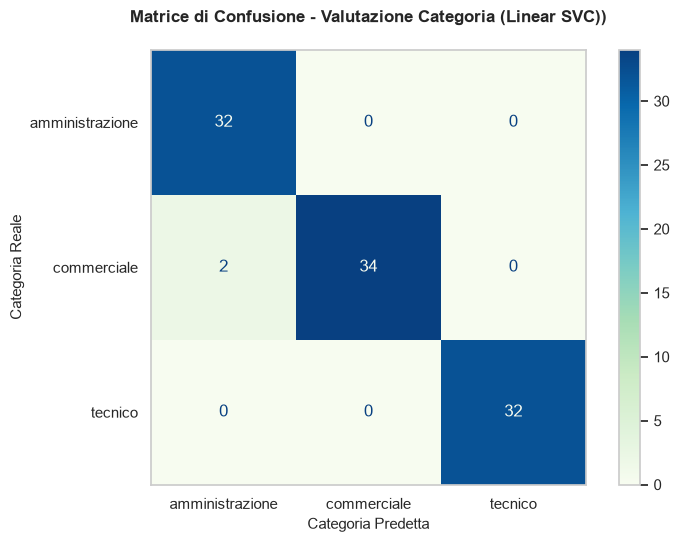

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.patheffects as path_effects

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_categoria.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_categoria.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Categoria (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Categoria Predetta', fontsize=11)
ax.set_ylabel('Categoria Reale', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Algoritmo di classificazione Random Forest

Citando il sito [SnowFlake](https://www.snowflake.com/it/fundamentals/random-forest/):
- Random forest (foresta casuale) è uno degli algoritmi più potenti e diffusi utilizzati nella creazione di modelli di machine learning.
- Questo modello di apprendimento supervisionato costruisce numerosi alberi decisionali e combina le loro previsioni per produrre risultati più accurati e robusti.

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---
Accuracy Totale: 0.9700

                 precision    recall  f1-score   support

amministrazione       0.97      0.94      0.95        32
    commerciale       1.00      0.97      0.99        36
        tecnico       0.94      1.00      0.97        32

       accuracy                           0.97       100
      macro avg       0.97      0.97      0.97       100
   weighted avg       0.97      0.97      0.97       100



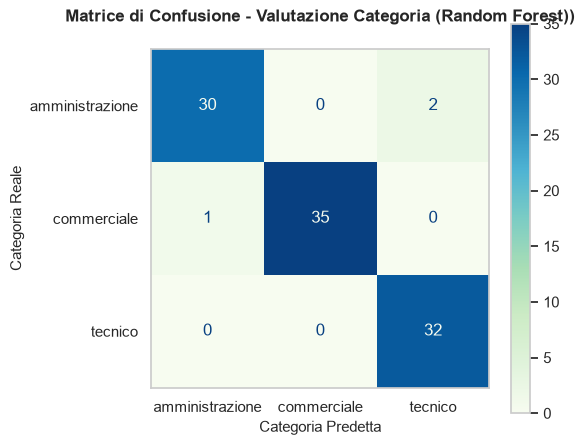

In [19]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['amministrazione', 'commerciale', 'tecnico']
print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Categoria (Random Forest))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Categoria Predetta', fontsize=11)
ax.set_ylabel('Categoria Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 4: Modello classificazione priorità

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la priorità di un ticket. 

Proprio come nella fase precedente, sono stati analizzati diversi algoritmi. A seguire è possibile consultarne l'elaborazione.

## Valutazione priorità con Linear SVC

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['priority']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#estrazione delle Feature con TF-IDF
vectorizer_priorità = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=None #inserendo le stopword italiane con nltk il risultato peggiora
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_priorità.fit_transform(X_train)
X_test_tfidf = vectorizer_priorità.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_priorità = LinearSVC(random_state=42, dual=False)
modello_priorità.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_priorità.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---
Accuracy Totale: 0.7500

Report di Classificazione (comprende F1-Macro):
              precision    recall  f1-score   support

        alta       0.78      0.88      0.83        33
       bassa       0.71      0.83      0.76        35
       media       0.77      0.53      0.63        32

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.74       100
weighted avg       0.75      0.75      0.74       100



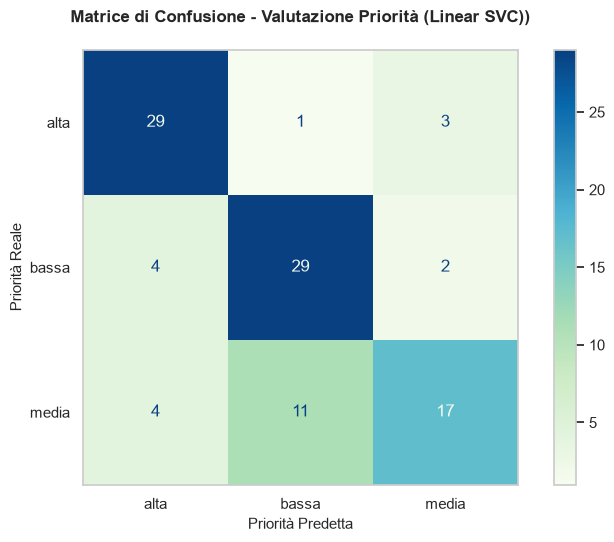

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_priorità.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_priorità.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Priorità (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Valutazione priorità con Random Forest

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---
Accuracy Totale: 0.7100

              precision    recall  f1-score   support

        alta       0.79      0.94      0.86        33
       bassa       0.68      0.77      0.72        35
       media       0.62      0.41      0.49        32

    accuracy                           0.71       100
   macro avg       0.70      0.71      0.69       100
weighted avg       0.70      0.71      0.69       100



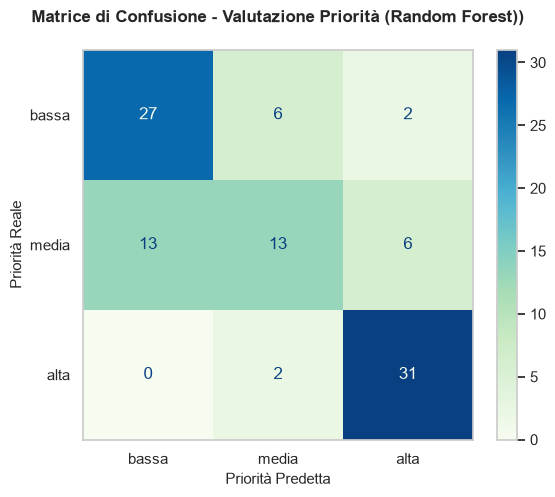

In [22]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['bassa', 'media', 'alta']
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Priorità (Random Forest))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

## Valutazione categoria con approccio gerarchico usando Linear SVC

Un altro approccio è stato quello di un addestramento gerarchico. Questa logica consiste nel addestrare inizialmente il modello nella classificazione delle Categorie e poi addestrarre in maniera verticale dei modelli di priorità per ogni reparto. 

Questo approccio è stato purtroppo fallimentare con tutti i dataset testati, complice la loro dimensione. Avendo a disposizione solo 500 ticket divisi in maniera equa (mediamente 166 ticket per tipo), il problema principale di questa tecnica era proprio il fatto che si creassero dei sotto-dataset troppo piccoli. Riporto comunque la logica utilizzata in quanto ho trovato l'approccio potenzialmente utilizzabile in un potenziale miglioramento del progetto.

Fase 1 (Isolata): Addestramento locale del modello di classificazione delle Categorie...
Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...
Fase 3: Esecuzione della pipeline sul Test Set...

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico) ---
Accuracy Complessiva sulla Priorità: 70.00%

              precision    recall  f1-score   support

        Alta       0.76      0.88      0.82        33
       Bassa       0.66      0.77      0.71        35
       Media       0.67      0.44      0.53        32

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.69       100
weighted avg       0.70      0.70      0.69       100



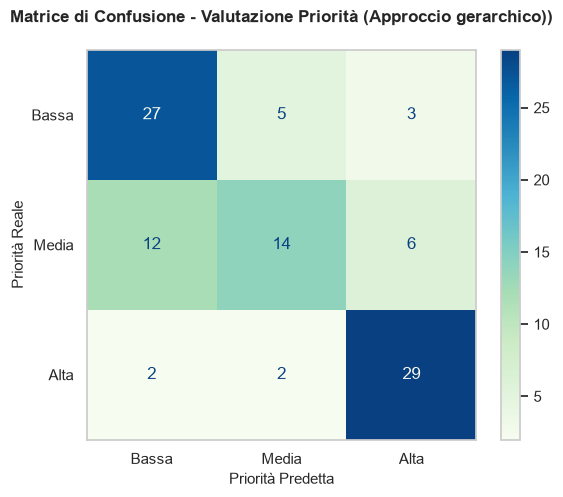

In [23]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#recupero dei dati
train_df = df.loc[X_train.index].copy()
test_df = df.loc[X_test.index].copy()

train_df['testo_completo'] = train_df['title'].fillna('') + " " + train_df['body'].fillna('')
test_df['testo_completo'] = test_df['title'].fillna('') + " " + test_df['body'].fillna('')

#modello per la categorie
print("Fase 1 (Isolata): Addestramento locale del modello di classificazione delle Categorie...")

vec_cat_gerarchico = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 2), stop_words=None)
X_train_cat_gerarchico = vec_cat_gerarchico.fit_transform(train_df['testo_completo'])
X_test_cat_gerarchico = vec_cat_gerarchico.transform(test_df['testo_completo'])

mod_cat_gerarchico = LinearSVC(random_state=42, dual=False)
mod_cat_gerarchico.fit(X_train_cat_gerarchico, train_df['category'])

#predizione delle categorie (Tecnico, Amministrazione, Commerciale)
test_df['pred_category'] = mod_cat_gerarchico.predict(X_test_cat_gerarchico)

#addestramento modelli di priorità per la categoria
print("Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...")
elenco_categorie = train_df['category'].unique()

modelli_priorita_reparto = {}
vectorizers_priorita_reparto = {}

for cat in elenco_categorie:
    #filtra i dati del TRAIN SET per la categoria corrente
    train_sottogruppo = train_df[train_df['category'] == cat]
    
    vec_prio = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
    X_train_prio_sub = vec_prio.fit_transform(train_sottogruppo['testo_completo'])
    
    clf_prio_sub = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    clf_prio_sub.fit(X_train_prio_sub, train_sottogruppo['priority'])
    
    modelli_priorita_reparto[cat.lower().strip()] = clf_prio_sub
    vectorizers_priorita_reparto[cat.lower().strip()] = vec_prio

#pipeline gerarchico del test set
print("Fase 3: Esecuzione della pipeline sul Test Set...")
priorita_predette_finali = []

for idx, riga in test_df.iterrows():
    categoria_stimata = str(riga['pred_category']).lower().strip()
    testo_ticket = riga['testo_completo']
    
    if categoria_stimata in vectorizers_priorita_reparto:
        vettorizzatore_specifico = vectorizers_priorita_reparto[categoria_stimata]
        modello_specifico = modelli_priorita_reparto[categoria_stimata]
        
        testo_vettorizzato = vettorizzatore_specifico.transform([testo_ticket])
        prio_stimata = modello_specifico.predict(testo_vettorizzato)[0]
    else:
        prio_stimata = riga['priority'] 
        
    priorita_predette_finali.append(prio_stimata)

test_df['pred_priority'] = priorita_predette_finali

#valutazione dell'approccio gerarchico
print("\n" + "="*60)
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico) ---")
print("="*60)

# Garantiamo la corrispondenza esatta delle stringhe per evitare il ValueError nella matrice
test_df['priority'] = test_df['priority'].str.strip().str.capitalize()
test_df['pred_priority'] = test_df['pred_priority'].str.strip().str.capitalize()

acc_prio = accuracy_score(test_df['priority'], test_df['pred_priority'])
print(f"Accuracy Complessiva sulla Priorità: {acc_prio*100:.2f}%\n")
print(classification_report(test_df['priority'], test_df['pred_priority']))

# Matrice di Confusione protetta
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(test_df['priority'], test_df['pred_priority'], labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='GnBu', ax=ax, values_format='d')
plt.title('Matrice di Confusione - Valutazione Priorità (Approccio gerarchico))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 5: Esportazione dei Modelli

In [24]:
import joblib

# Salviamo i componenti chiave del sistema
joblib.dump(modello_categoria, 'modelli/m_categoria.pkl')
joblib.dump(vectorizer_categoria, 'modelli/v_categoria.pkl')

# Salviamo anche i dizionari dei modelli verticali delle priorità
joblib.dump(modello_priorità, 'modelli/m_priorità.pkl')
joblib.dump(vectorizer_priorità, 'modelli/v_priorità.pkl')

print("Tutti i modelli e i vettorizzatori sono stati serializzati con successo!")

Tutti i modelli e i vettorizzatori sono stati serializzati con successo!


# Fase 6: Valutazione generale dei vari modelli nei dataset analizzati

La farò non appena avrò deciso ufficialmente i 3 dataset da prendere come riferimento